In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
sns.set_style("whitegrid")

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 22,
    "axes.titlesize": 22
})

In [5]:
results = pd.read_csv("results.csv")

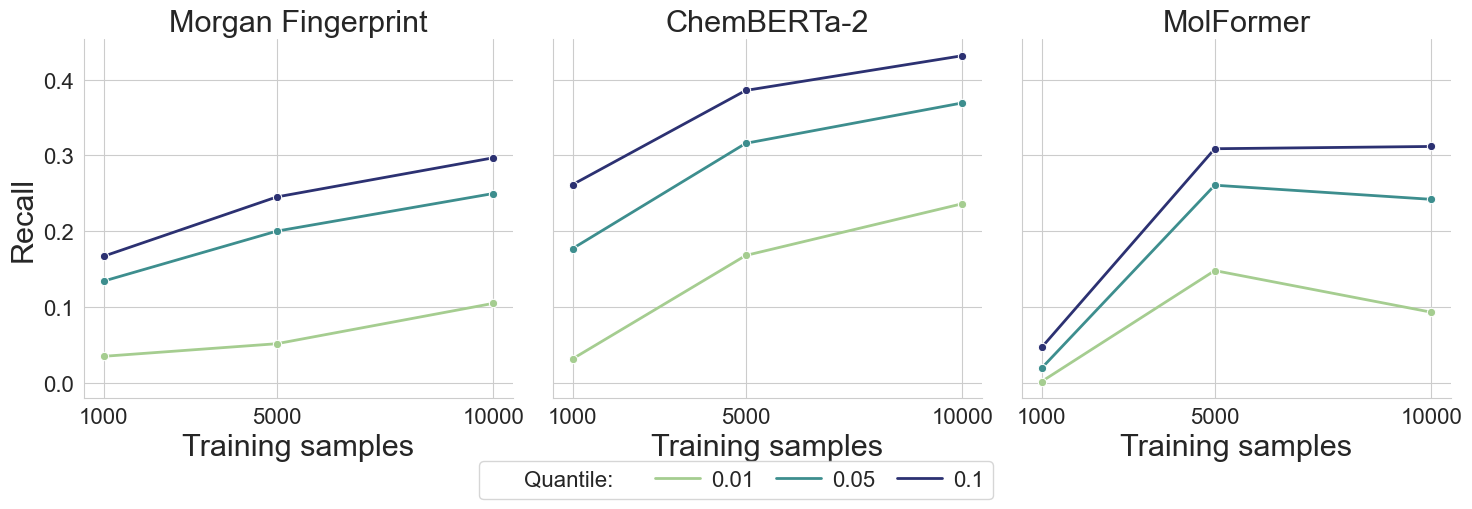

In [13]:
g = sns.relplot(
    results,
    x="Training samples",
    y="Recall",
    hue="Quantile",
    col="Feature",
    kind="line",
    palette="crest",
    marker="o",
    legend=False,
)

g.set_titles(col_template="{col_name}")

from matplotlib import colormaps
from matplotlib.lines import Line2D

cm = colormaps["crest"]
colors = cm(plt.Normalize()([0.01, 0.05, 0.1]))

legend_elements = [
    Line2D([0], [0], color="white", label="Quantile:", visible=False),
    Line2D([0], [0], color=colors[0], label="0.01"),
    Line2D([0], [0], color=colors[1], label="0.05"),
    Line2D([0], [0], color=colors[2], label="0.1"),
]

# Get the figure object
fig = plt.gcf()

# Add the combined legend to the figure
legend = fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=4,
    columnspacing=1,
    handletextpad=0.5,
)

# Adjust the appearance of the legend
for text in legend.get_texts():
    if text.get_text() in ["Quantile:"]:
        text.set_ha("left")  # Align category labels to the left
        text.set_position((-20, 0))  # Adjust the position as needed

# Adjust the subplot layout to make room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

g.map(lambda color: plt.gca().set_xticks([1000, 5000, 10_000]))
g.savefig("baseline_recall.svg", format="svg")

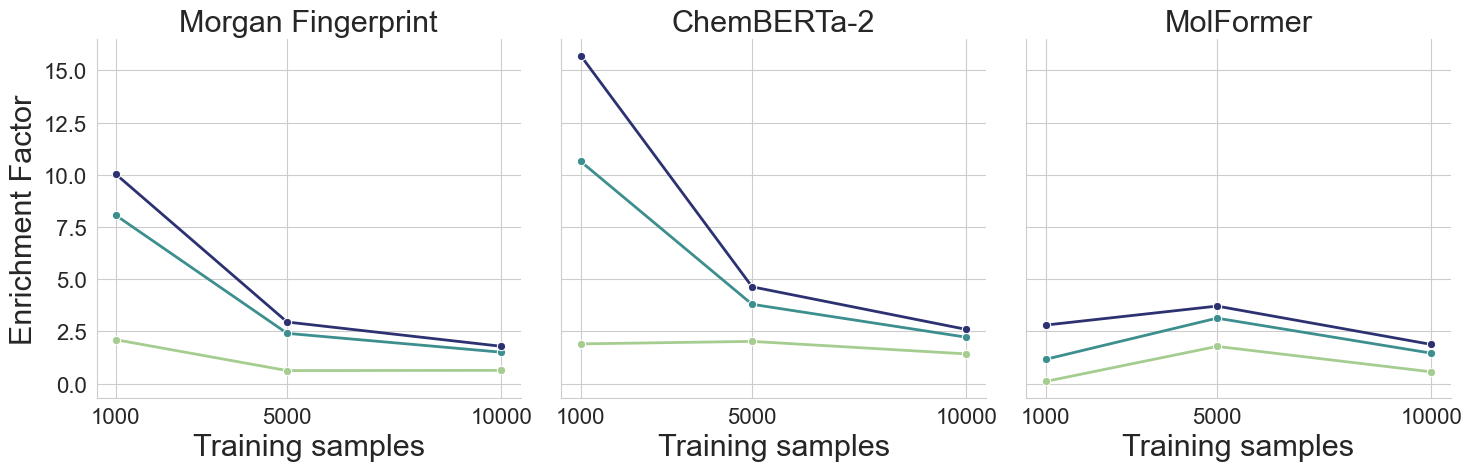

In [15]:
g = sns.relplot(
    results,
    x="Training samples",
    y="Enrichment Factor",
    hue="Quantile",
    col="Feature",
    kind="line",
    palette="crest",
    marker="o",
    legend=None
)

g.set_titles(col_template="{col_name}")

g.map(lambda color: plt.gca().set_xticks([1000, 5000, 10_000]))
g.savefig("baseline_ef.svg", format="svg")